# Sequential Chain




## Install dependencies
Run this once in a fresh environment.


In [2]:
%pip -q install langgraph langchain-openai python-dotenv

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1) Imports

In [3]:
import os
from dotenv import load_dotenv
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

## 2) Load environment variables - please read instructions carefully

In [4]:
# if you are running in local, uncomment below line. also make sure you shall have a .env file
load_dotenv()

True

In [5]:
# if you are running in google colab, uncomment below line. and replace "Your_API_Key" with your own openAI API key
#os.environ["OPENAI_API_KEY"] = "Your_API_Key"

## 3) Define Node

In [6]:
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0.4
)

# llm = ChatOpenAI(
#     model="gpt-4.1-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0.4
# )

class ResearchState(TypedDict):
    topic: str
    research_facts: str
    summary: str
    report: str
    status: str
    error: str



def research_node(state: ResearchState):
    try:
        response = llm.invoke(
            f"Research this topic thoroughly:\n\n{state['topic']}"
        )
        return {"research_facts": response.content}
    except Exception as e:
        return {
            "research_facts": "",
            "status": "error",
            "error": f"Research failed: {str(e)}"
        }


def summarise_node(state: ResearchState):
    try:
        response = llm.invoke(
            f"Write a concise 3-sentence summary of this research:\n\n{state['research_facts']}"
        )
        return {"summary": response.content}
    except Exception as e:
        return {
            "summary": "",
            "status": "error",
            "error": f"Summarization failed: {str(e)}"
        }


def report_node(state: ResearchState):
    try:
        response = llm.invoke(
            f"Format this into a professional executive brief:\n\n{state['summary']}"
        )
        return {"report": response.content}
    except Exception as e:
        return {
            "report": "",
            "status": "error",
            "error": f"Format failed: {str(e)}"
        }

## 4) Build the sequential chain

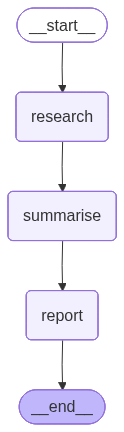

In [7]:
builder = StateGraph(ResearchState)

#each node calls a llm in this case
builder.add_node("research", research_node)
builder.add_node("summarise", summarise_node)
builder.add_node("report", report_node)

builder.add_edge(START, "research") #from START to research
builder.add_edge("research", "summarise") #from research to summarise
builder.add_edge("summarise", "report") #from summarise to report
builder.add_edge("report", END) #from report to END

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


## 4) Run

In [8]:
result = graph.invoke({
    "topic": "quantum computing applications in finance"
})

print(result["report"])

**Executive Brief: Quantum Computing in Finance**

Quantum computing presents significant opportunities for the financial sector by utilizing advanced quantum algorithms to address complex challenges such as portfolio optimization, risk analysis, and derivative pricing with greater efficiency than traditional methods. Although current quantum hardware remains limited and algorithm development is in its early stages, leading financial institutions have initiated pilot projects that showcase potential improvements in computational speed and machine learning capabilities.

Continued research and advancements in quantum hardware are expected to drive practical quantum advantages in finance within the next 5 to 10 years, positioning the industry to benefit from enhanced decision-making and operational efficiencies.
